In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [ ]:
# 훈련세트 테스트세트 분할
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,random_state=42)

# 이상치 탐지 라이브러리
# 정상데이터보다 이상치는 더 쉽게(적은 분할로) 고립된다
# 랜던하게 feature선택 랜덤하게 split value 선택 -> 계속.. 어떤 데이터가 얼마나 빨리 고립되는가
# 트리알고리즘, 이상치는 적은 분할회수로고립, 트리가 깊지 않음
from sklearn.ensemble import IsolationForest # 이상치를 자동으로 찾아내는 알고리즘
isolation_forest = IsolationForest(random_state=42)
housing_numeric_for_outlier = train_set.drop('ocean_proximity',axis=1).dropna()  # 결측치를 제거해서 원본대비 줄었음
housing_numeric_for_outlier.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0


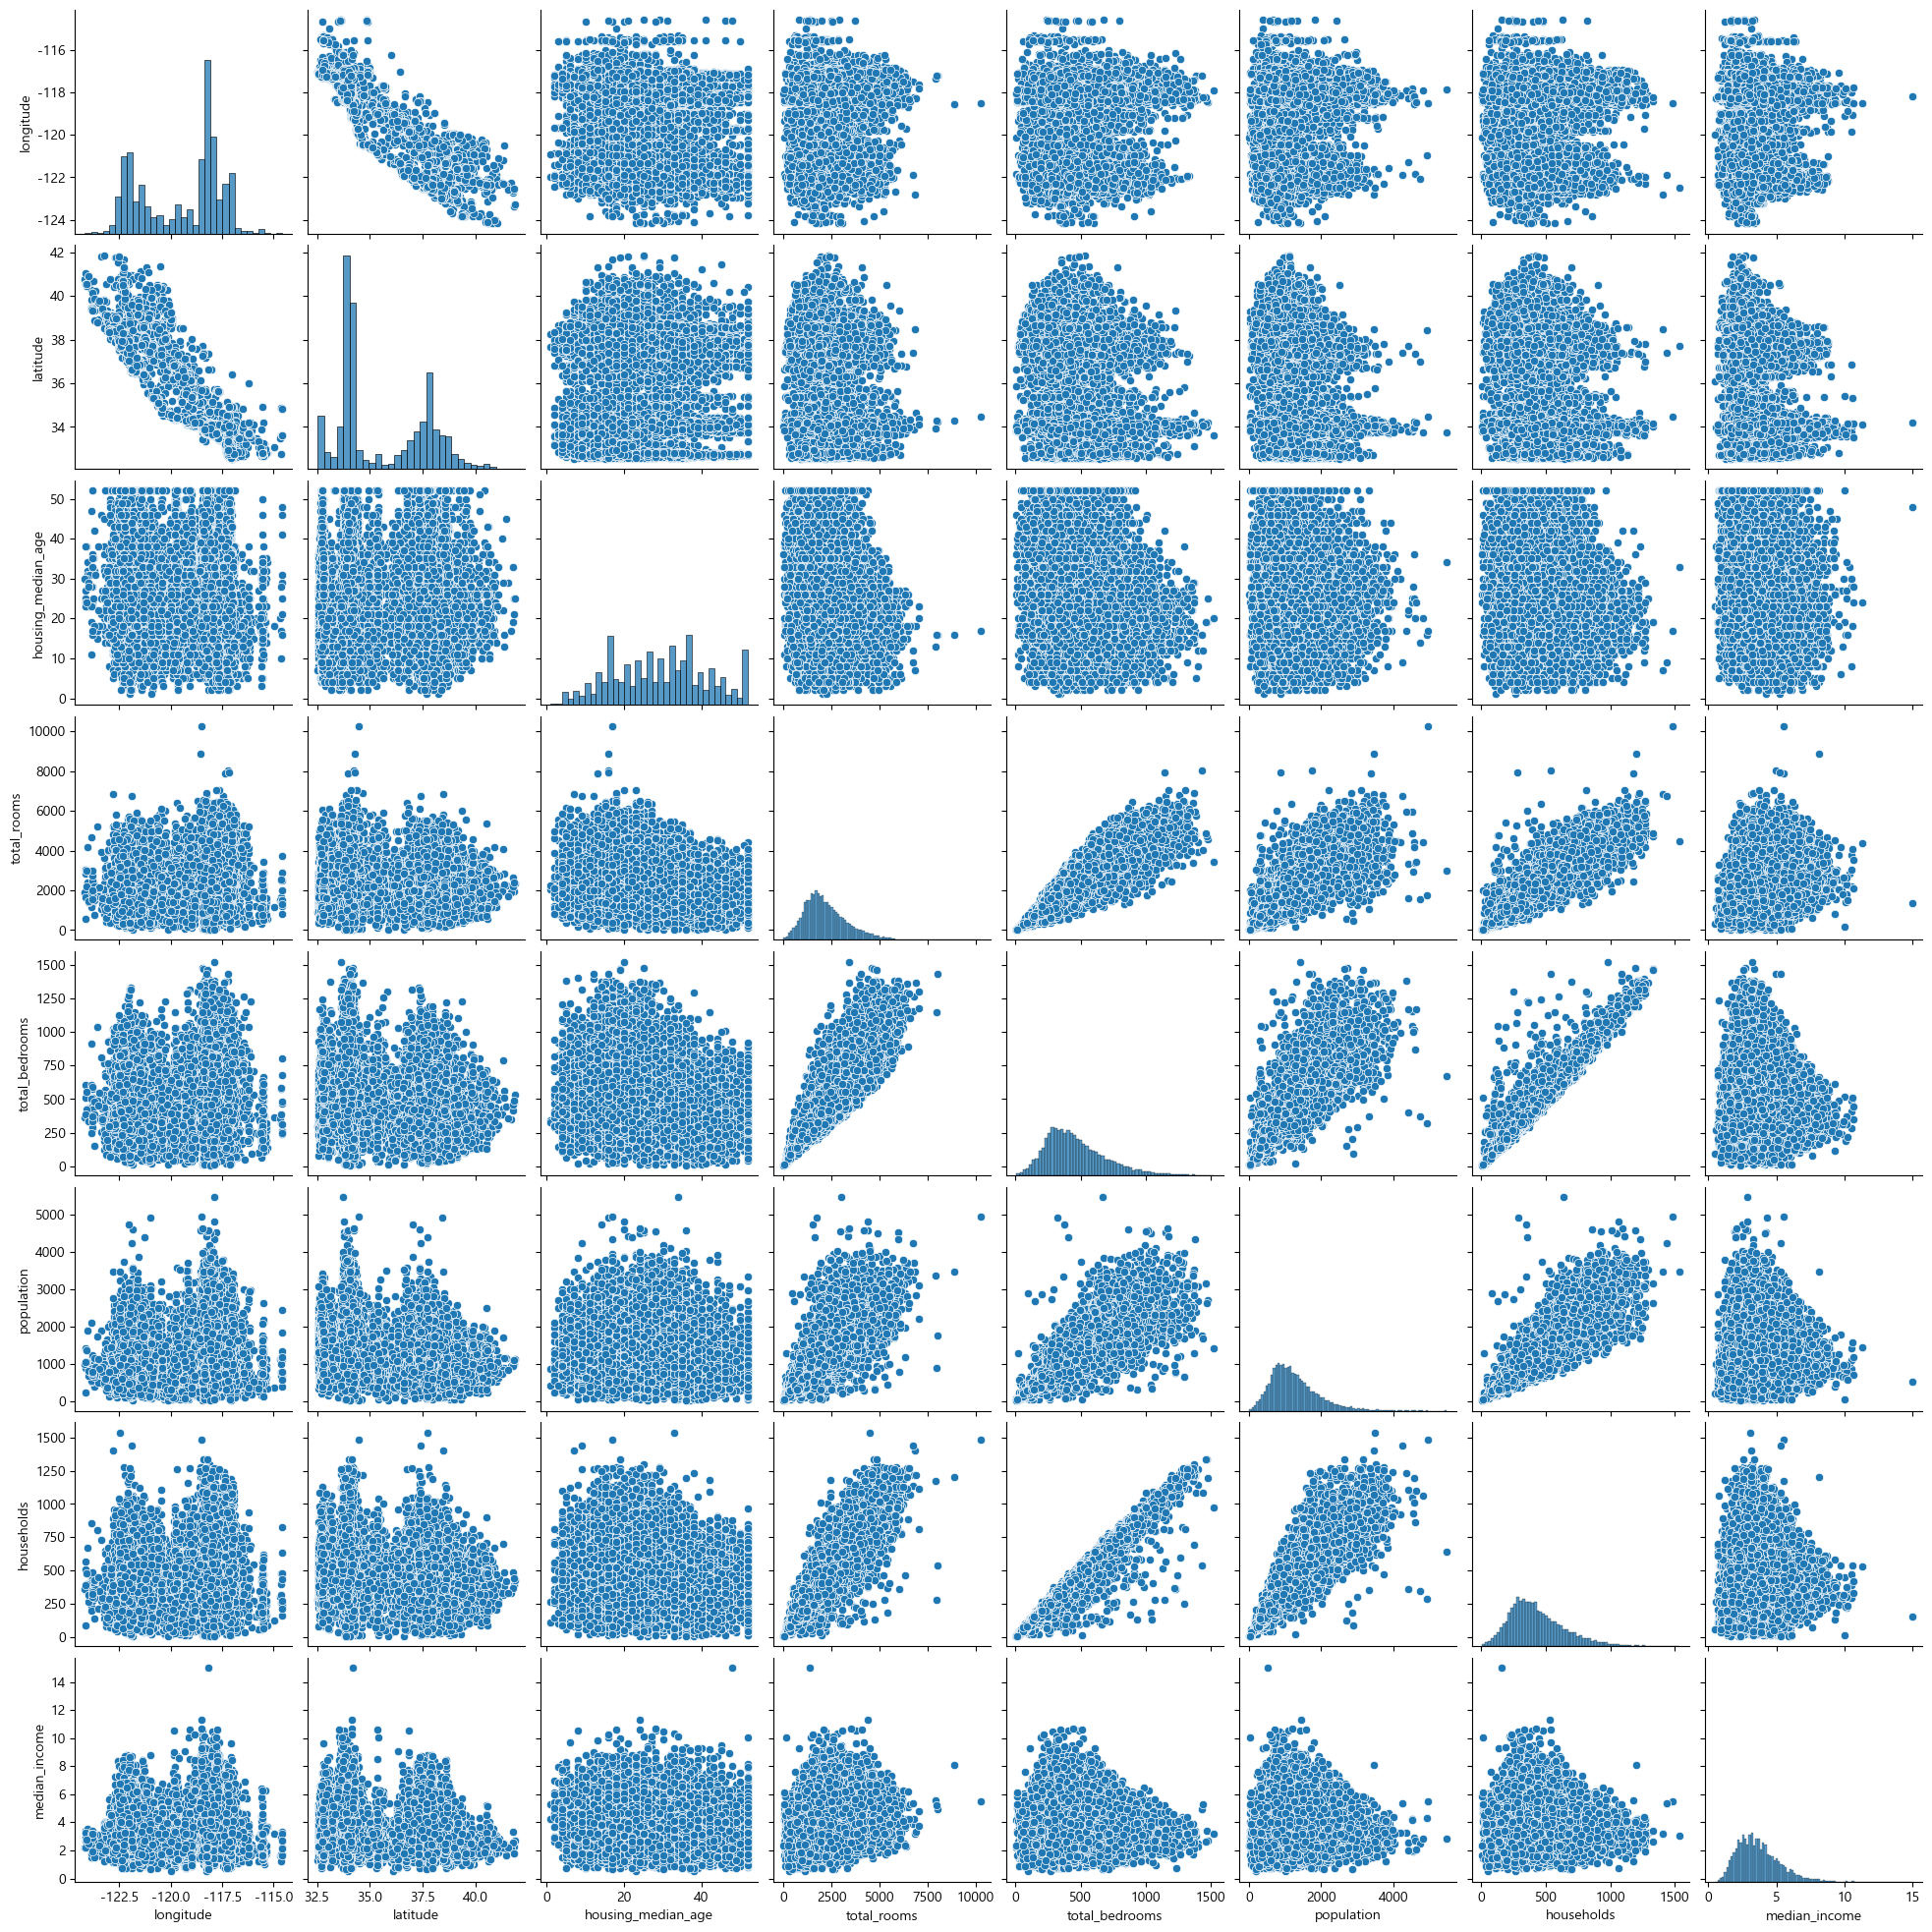

In [ ]:
#
outlier_pred = pd.Series(1,index = train_set.index)  # 결측치 제거로 줄었으니. 다시 원래대로 복원(인데스의 value를 1로 맞춤)
outlier_pred.loc[housing_numeric_for_outlier.index] = isolation_forest.fit_predict(housing_numeric_for_outlier)
# 정상 1 이상치 -1
train_set_clean = train_set[outlier_pred == 1]

# x y 분리
train_set_clean
housing = train_set_clean.drop('median_house_value',axis=1)  #정답제거된 학습용 데이터
housing_label = train_set_clean['median_house_value'].copy()  # 정답

# 데이터의 분포가 한쪽으로 치우쳐진 즉 꼬리가긴 왜도를 찾기
import seaborn as sns
sns.pairplot(housing)

In [4]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')

In [ ]:
import numpy as np
#왜도 컬럼
skewed_attribs =  ['total_rooms','total_bedrooms', 'population','households','median_income']
# 왜도가 있는 열 로그변환 필요
#수치형 컬럼
num_attribs = ['longitude','latitude','housing_median_age']
# 범주형 컬럼
cat_attribs = ['ocean_proximity']

# 파이프라인
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

log_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    # 로그변환 적용 : np.log1p = log(x + 1) : +1은 x 가 0일때 무한대가 되는 것을 방지
    # feature_names_out='one-to-one : 열 이름 유지
    ('scaler',StandardScaler())
])
# 범주형 부분과 최종 파이프라인
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([  # 열마다 다른 전처리를 병렬 적용
    ('num',num_pipeline,num_attribs),
    ('log',log_pipeline,skewed_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

# 모델 선택
from sklearn.ensemble import RandomForestRegressor
full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state=42))
])
# 훈련
full_pipeline.fit(housing,housing_label)

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('log', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
full_pipeline.score(test_set.drop('median_house_value',axis=1),test_set['median_house_value'])

0.8089169059009034

In [7]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

# gridSearchCV를 이용해서 성능을 측정
# 튜닝 - 모델
param_grid = [
    {'random_forest__n_estimators':[30,100,200], 'random_forest__max_features':[2,4,6]}
]
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(full_pipeline, param_grid=param_grid,cv=3)
grid_search.fit(housing.drop('median_house_value', axis=1), housing['median_house_value'])

import random
random_5 = random.sample(range(len(housing)), 5)

print(f'최고의 파라메터 : {grid_search.best_params_}')
print(f'최고의 점수 : {grid_search.best_score_}')
best_model = grid_search.best_estimator_
predict_value = best_model.predict( housing.iloc[random_5].drop('median_house_value',axis=1) )
print(predict_value)

최고의 파라메터 : {'random_forest__max_features': 6, 'random_forest__n_estimators': 200}
최고의 점수 : 0.8208977973711301
[242279.  105341.5  67661.5 227269.5 210343. ]


In [8]:
# 교차검증
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
housing_clean = housing.dropna().copy()
scores = cross_val_score(model , housing_clean.drop(['median_house_value','ocean_proximity'],axis=1) , 
                         housing_clean['median_house_value'] ,cv=5)

In [9]:
# cv 파라메터에 들어갈 알고리즘(폴더객체)
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)
x = np.arange(10)
for train_idx, val_idx in kfold.split(x):
    print(train_idx, val_idx)

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [10]:
# 분류에서 
from sklearn.model_selection import StratifiedKFold
sk = StratifiedKFold(n_splits=5) 

In [11]:
# 교차검증
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
housing_clean = housing.dropna().copy()
scores = cross_val_score(model , housing_clean.drop(['median_house_value','ocean_proximity'],axis=1) , 
                         housing_clean['median_house_value'] ,cv=kfold)